# Complex CNN với Parallel Block

Phân loại 38 lớp bệnh lá cây từ bộ dữ liệu PlantVillage.

1. Import thư viện và cấu hình
2. Nạp dữ liệu và xử lý ảnh
3. Xây dựng Complex CNN
4. Huấn luyện
5. Đánh giá trên tập test

Model tốt nhất được giữ trong bộ nhớ trong lúc chạy notebook, không tự động lưu ra file.

## Bước 1 – Import thư viện và cấu hình

Đặt batch size, số epoch, learning rate và seed. Notebook sử dụng GPU CUDA để huấn luyện Complex CNN.

In [19]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Tìm thư mục gốc của project.
current_dir = Path.cwd().resolve()
possible_dirs = [
    current_dir,
    current_dir / "plant-disease-classification",
    current_dir.parent,
]

PROJECT_DIR = None

for folder in possible_dirs:
    has_readme = (folder / "README.md").is_file()
    has_notebooks = (folder / "notebooks").is_dir()

    if has_readme and has_notebooks:
        PROJECT_DIR = folder
        break

if PROJECT_DIR is None:
    raise FileNotFoundError("Không tìm thấy thư mục project.")

print("Project:", PROJECT_DIR)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Notebook này yêu cầu GPU NVIDIA có CUDA.
if not torch.cuda.is_available():
    raise RuntimeError("Không tìm thấy GPU CUDA.")

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Project: D:\Plant_disease\plant-disease-classification
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Bước 2 – Nạp dữ liệu và xử lý ảnh

Đọc `preprocessing_data.csv` được tạo bởi notebook preprocessing, sau đó tạo Dataset và DataLoader. CPU mở ảnh, chuyển sang RGB và resize về 224×224; batch train được chuyển lên GPU để augmentation.

In [20]:
DATA_DIR = PROJECT_DIR.parent / "PlantVillage"
PREPROCESSING_PATH = (
    PROJECT_DIR / "outputs" / "results" / "preprocessing_data.csv"
)

if not PREPROCESSING_PATH.is_file():
    raise FileNotFoundError(
        "Không tìm thấy preprocessing_data.csv. "
        "Hãy chạy 02_preprocessing.ipynb trước."
    )

processed_df = pd.read_csv(PREPROCESSING_PATH)

required_columns = {
    "relative_path",
    "class_name",
    "class_id",
    "split",
}
missing_columns = required_columns - set(processed_df.columns)
if missing_columns:
    raise ValueError(f"Thiếu cột: {sorted(missing_columns)}")

# Lấy danh sách lớp theo đúng thứ tự class_id.
class_table = processed_df[["class_id", "class_name"]].drop_duplicates()
class_table = class_table.sort_values("class_id")
class_names = class_table["class_name"].tolist()
num_classes = len(class_names)

IMAGE_SIZE = 224
# Batch 64 đã được kiểm tra trên RTX 3050 6GB.
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

print("Number of classes:", num_classes)
print("Preprocessing data:", PREPROCESSING_PATH)
print(processed_df["split"].value_counts())

class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform):
        self.paths = dataframe["relative_path"].astype(str).tolist()
        self.labels = dataframe["class_id"].astype(int).tolist()
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        relative_path = self.paths[index].replace("\\", "/")
        image_path = self.data_dir.joinpath(*relative_path.split("/"))
        label = self.labels[index]

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return image, label

Number of classes: 38
Preprocessing data: D:\Plant_disease\plant-disease-classification\outputs\results\preprocessing_data.csv
split
train         39089
test          10851
validation     4344
Name: count, dtype: int64


In [21]:
# Resize và chuyển ảnh thành tensor ngay khi DataLoader đọc ảnh.
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_df = processed_df[processed_df["split"] == "train"]
val_df = processed_df[processed_df["split"] == "validation"]
test_df = processed_df[processed_df["split"] == "test"]

train_dataset = PlantDiseaseDataset(train_df, DATA_DIR, image_transform)
val_dataset = PlantDiseaseDataset(val_df, DATA_DIR, image_transform)
test_dataset = PlantDiseaseDataset(test_df, DATA_DIR, image_transform)

# Kiểm tra ảnh gốc có tồn tại.
first_image_path = DATA_DIR.joinpath(
    *train_dataset.paths[0].replace("\\", "/").split("/")
)

if not first_image_path.is_file():
    raise FileNotFoundError(
        "Không tìm thấy ảnh trong PlantVillage."
    )

# num_workers=0 và pin_memory=False giúp code ổn định trên Windows.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

# Các phép augmentation này nhận tensor CUDA và trả về tensor CUDA.
gpu_train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, scale=(0.90, 1.10)),
    transforms.ColorJitter(contrast=0.10),
])

def augment_images_on_gpu(images):
    return gpu_train_augmentation(images)

Train batches: 611
Validation batches: 68
Test batches: 170


## Bước 3 – Xây dựng Complex CNN

Parallel Block đưa cùng một đầu vào qua ba nhánh với các kernel khác nhau, sau đó ghép kết quả lại. Nội dung kiến trúc Complex CNN được giữ nguyên.

In [22]:
class ParallelBlock(nn.Module):
    def __init__(self, input_channels):
        super().__init__()

        # Nhánh 1: convolution 1x1.
        self.branch1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        # Nhánh 2: convolution 3x3.
        self.branch2 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        # Nhánh 3: convolution 5x5.
        self.branch3 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

    def forward(self, x):
        output1 = self.branch1(x)
        output2 = self.branch2(x)
        output3 = self.branch3(x)

        # 3 nhánh x 32 kênh = 96 kênh.
        output = torch.cat(
            [output1, output2, output3],
            dim=1,
        )

        return output

class ComplexCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.parallel_block = ParallelBlock(input_channels=64)

        self.block3 = nn.Sequential(
            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.average_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.output_layer = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.parallel_block(x)
        x = self.block3(x)

        x = self.average_pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.output_layer(x)

        return x

model = ComplexCNN(num_classes=num_classes)
model = model.to(device)

total_parameters = 0

for parameter in model.parameters():
    total_parameters += parameter.numel()

# Kiểm tra model bằng một batch giả nằm trên GPU.
sample_images = torch.zeros(
    2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device
)

with torch.no_grad():
    sample_outputs = model(sample_images)

print(model)
print("Model device:", next(model.parameters()).device)
print("Output shape:", sample_outputs.shape)
print(f"Total parameters: {total_parameters:,}")

ComplexCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (parallel_block): ParallelBlock(
    (branch1): Sequential(
      (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (branch2): Sequential(
      (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True

## Bước 4 – Huấn luyện

Huấn luyện Complex CNN bằng Adam, CrossEntropyLoss và mixed precision. Sau mỗi epoch, trọng số có validation loss thấp nhất được giữ trong bộ nhớ.

In [23]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

# Mixed precision giúp GPU RTX train nhanh hơn và dùng ít VRAM hơn.
scaler = torch.amp.GradScaler("cuda")

def train_one_epoch(model, dataloader):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    for images, labels in dataloader:
        # Chuyển batch từ RAM lên GPU.
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Augmentation được thực hiện trên GPU.
        images = augment_images_on_gpu(images)

        optimizer.zero_grad()

        # Forward và loss dùng mixed precision trên GPU.
        with torch.amp.autocast(device_type="cuda"):
            outputs = model(images)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_images += batch_size

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images

    return average_loss, accuracy

def evaluate(model, dataloader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = loss_function(outputs, labels)
            predictions = outputs.argmax(dim=1)
            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_images += batch_size

    average_loss = total_loss / total_images
    accuracy = total_correct / total_images

    return average_loss, accuracy

In [24]:
best_val_loss = float("inf")
best_epoch = 0
best_model_state = None

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader
    )

    val_loss, val_accuracy = evaluate(
        model, val_loader
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Giữ trọng số tốt nhất trong RAM.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("Best epoch:", best_epoch)

Epoch [1/10] | Train Loss: 1.7053 | Train Acc: 0.5382 | Val Loss: 1.3121 | Val Acc: 0.5808
Epoch [2/10] | Train Loss: 1.0407 | Train Acc: 0.6956 | Val Loss: 0.6980 | Val Acc: 0.7859
Epoch [3/10] | Train Loss: 0.8204 | Train Acc: 0.7550 | Val Loss: 0.7173 | Val Acc: 0.7705
Epoch [4/10] | Train Loss: 0.6867 | Train Acc: 0.7933 | Val Loss: 0.9082 | Val Acc: 0.7293
Epoch [5/10] | Train Loss: 0.5952 | Train Acc: 0.8183 | Val Loss: 0.4244 | Val Acc: 0.8729
Epoch [6/10] | Train Loss: 0.5281 | Train Acc: 0.8378 | Val Loss: 0.5577 | Val Acc: 0.8301
Epoch [7/10] | Train Loss: 0.4792 | Train Acc: 0.8506 | Val Loss: 0.3263 | Val Acc: 0.8978
Epoch [8/10] | Train Loss: 0.4400 | Train Acc: 0.8651 | Val Loss: 0.3148 | Val Acc: 0.9052
Epoch [9/10] | Train Loss: 0.3992 | Train Acc: 0.8754 | Val Loss: 0.4678 | Val Acc: 0.8582
Epoch [10/10] | Train Loss: 0.3783 | Train Acc: 0.8812 | Val Loss: 0.8569 | Val Acc: 0.7610
Best epoch: 8


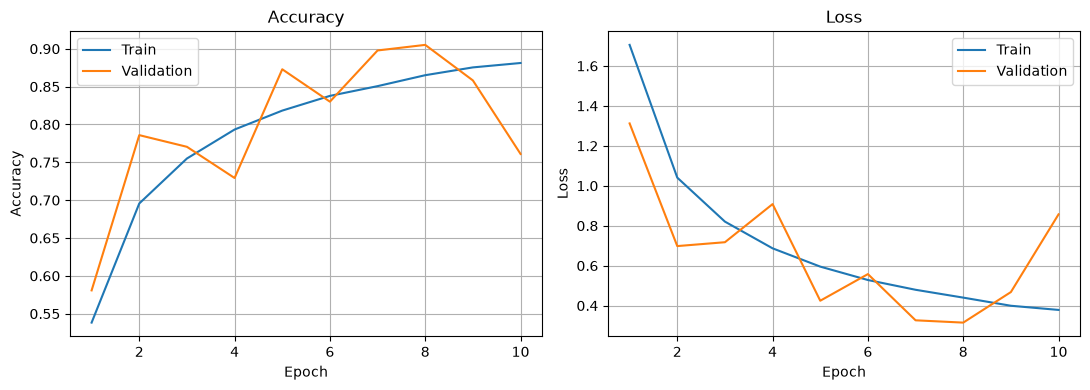

In [25]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_accuracy"], label="Train")
axes[0].plot(epochs, history["val_accuracy"], label="Validation")
axes[0].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy")
axes[0].legend()
axes[0].grid()

axes[1].plot(epochs, history["train_loss"], label="Train")
axes[1].plot(epochs, history["val_loss"], label="Validation")
axes[1].set(xlabel="Epoch", ylabel="Loss", title="Loss")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Bước 5 – Đánh giá trên tập test

Nạp lại trọng số tốt nhất trong bộ nhớ và tính test loss, accuracy, precision, recall cùng F1-score.

In [26]:
# Dùng lại trọng số tốt nhất đang được giữ trong RAM.
if best_model_state is None:
    raise ValueError("Chưa có trọng số model. Hãy chạy phần huấn luyện trước.")

model.load_state_dict(best_model_state)

test_loss, test_accuracy = evaluate(model, test_loader)

all_predictions = []
all_labels = []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())

precision, recall, f1_score, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0,
)

metrics = {
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1_score),
}

print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")

Test Loss : 0.3205
Accuracy  : 0.9012
Precision : 0.9134
Recall    : 0.9008
F1-score  : 0.9008


## Confusion matrix cho nhóm Tomato

Ma trận này chỉ hiển thị 10 lớp bệnh của Tomato. Những mẫu Tomato bị dự đoán sang nhóm cây khác được đếm riêng và không nằm trong 10 cột của ma trận.

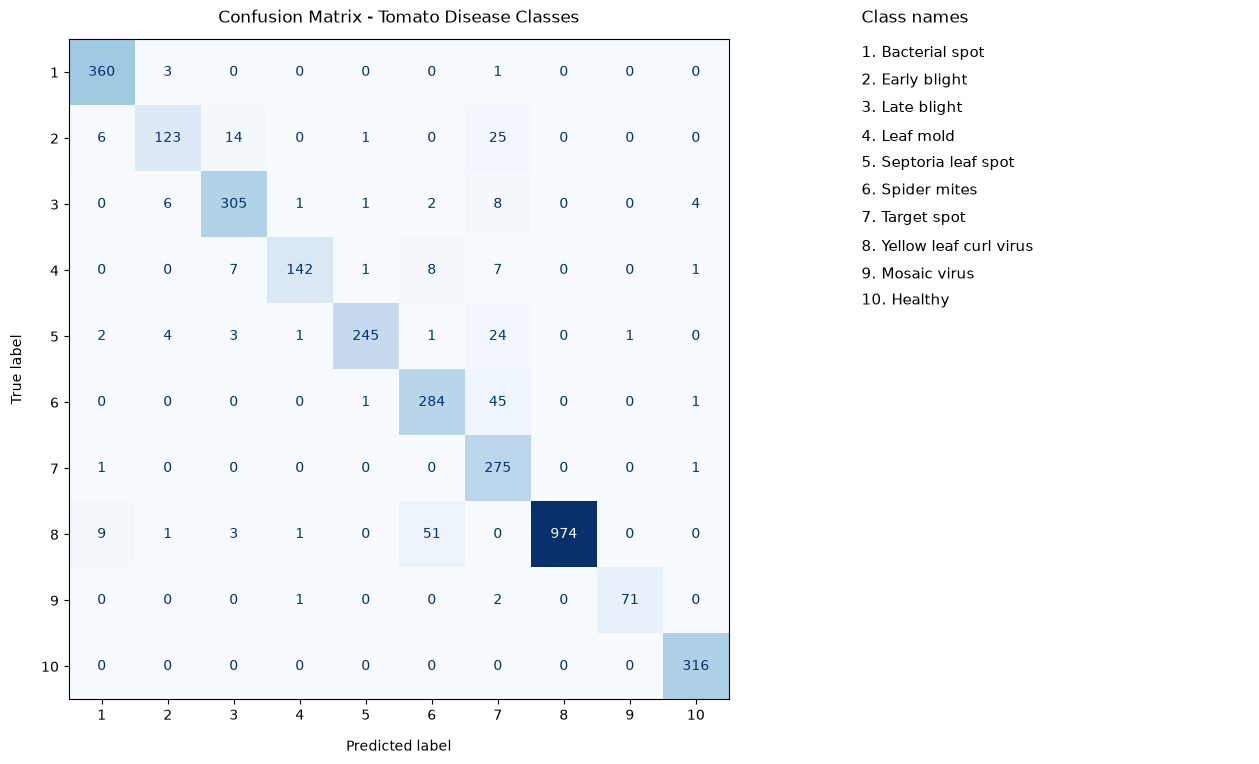

Số ảnh Tomato: 3626
Accuracy nhóm Tomato: 85.36%
Dự đoán sang nhóm cây khác: 282


In [28]:
# Lấy 10 lớp có tên bắt đầu bằng Tomato___.
tomato_classes = [
    name for name in class_names
    if name.startswith("Tomato___")
]

if len(tomato_classes) != 10:
    raise ValueError(
        f"Cần 10 lớp Tomato nhưng tìm thấy {len(tomato_classes)}."
    )

tomato_ids = [class_names.index(name) for name in tomato_classes]

# Tên ngắn giúp nhãn không bị chồng hoặc cắt khỏi biểu đồ.
short_names = {
    "Bacterial_spot": "Bacterial\nspot",
    "Early_blight": "Early\nblight",
    "Late_blight": "Late\nblight",
    "Leaf_Mold": "Leaf\nmold",
    "Septoria_leaf_spot": "Septoria\nleaf spot",
    "Spider_mites Two-spotted_spider_mite": "Spider\nmites",
    "Target_Spot": "Target\nspot",
    "Tomato_Yellow_Leaf_Curl_Virus": "Yellow leaf\ncurl virus",
    "Tomato_mosaic_virus": "Mosaic\nvirus",
    "healthy": "Healthy",
}
tomato_names = [
    short_names[name.replace("Tomato___", "")]
    for name in tomato_classes
]

labels_array = np.array(all_labels)
predictions_array = np.array(all_predictions)

# Chỉ lấy các ảnh có nhãn thật thuộc nhóm Tomato.
tomato_mask = np.isin(labels_array, tomato_ids)
tomato_true = labels_array[tomato_mask]
tomato_pred = predictions_array[tomato_mask]

if len(tomato_true) == 0:
    raise ValueError("Tập test không có ảnh Tomato.")

tomato_matrix = confusion_matrix(
    tomato_true,
    tomato_pred,
    labels=tomato_ids,
)

# Dùng số 1-10 trên hai trục để tên lớp không bao giờ bị chồng nhau.
class_numbers = [str(number) for number in range(1, 11)]

fig, (ax, note_ax) = plt.subplots(
    1,
    2,
    figsize=(14, 8),
    gridspec_kw={"width_ratios": [3.2, 1.3]},
)
ConfusionMatrixDisplay(
    confusion_matrix=tomato_matrix,
    display_labels=class_numbers,
).plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=0,
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion Matrix - Tomato Disease Classes", pad=12)
ax.set_xlabel("Predicted label", labelpad=12)
ax.set_ylabel("True label", labelpad=12)
ax.tick_params(axis="both", labelsize=10)

# Ghi chú tên của từng lớp ở bên phải biểu đồ.
note_ax.axis("off")
note_ax.set_title("Class names", loc="left", pad=12)
class_note = "\n".join(
    f"{number}. {name.replace(chr(10), ' ')}"
    for number, name in zip(class_numbers, tomato_names)
)
note_ax.text(0, 1, class_note, va="top", fontsize=11, linespacing=1.8)

fig.tight_layout(pad=2)
plt.show()

outside_count = (~np.isin(tomato_pred, tomato_ids)).sum()
tomato_accuracy = (tomato_true == tomato_pred).mean()

print("Số ảnh Tomato:", len(tomato_true))
print(f"Accuracy nhóm Tomato: {tomato_accuracy:.2%}")
print("Dự đoán sang nhóm cây khác:", outside_count)